# M3/M5 — ACHPR Case Law Analysis

Analysis of the ACHPR case law dataset (30 cases) for Ch.3 (functional criterion emergence) and Ch.4 (doctrinal concepts, cross-system citations).

**Data sources:**
- `data/achpr_cases.json` — 30 coded ACHPR/African Court decisions
- `data/case_law_analysis.json` — doctrinal concepts + cross-system citations
- `src/data.js` — constitutional recognition data (for pre/post-Ogiek analysis)

**Thesis chapters served:** Ch.3 (functional criterion emergence), Ch.4 S1 (doctrinal concepts), Ch.4 S2 (cross-system citations), Ch.5 (self-determination evolution)

> **Methodological note:** The case law dataset is extracted from 3 docx files covering sessions 70-81 plus 2 landmark cases (Endorois, Ogiek) added manually. It is NOT exhaustive — it represents the cases Alex has analyzed so far. The functional criterion coding is preliminary and requires legal validation.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import re
from pathlib import Path
from collections import Counter

# Shared thesis style + bilingual helpers
import sys; sys.path.insert(0, str(Path('..') / 'scripts'))
from figure_style import *
apply_style()

# Load data
with open('../data/achpr_cases.json') as f:
    cases = json.load(f)

with open('../data/case_law_analysis.json') as f:
    analysis = json.load(f)

# Load constitutional data for pre/post-Ogiek
with open('../src/data.js') as f:
    raw = f.read()
    start = raw.index('{')
    end = raw.rindex('}') + 1
    DATA = json.loads(raw[start:end])

print(f'Cases: {len(cases)}')
print(f'Doctrinal concepts: {len(analysis["doctrinal_concepts"])}')
print(f'Cross-system citations: {len(analysis["cross_system_citations"])}')

Cases: 30
Doctrinal concepts: 14
Cross-system citations: 6


## 1. Data Preparation

Parse dates, extract filing years, classify cases by peoples' rights invocation.

In [2]:
# Extract filing year from case_number (e.g., 298/05 -> 2005, 006/2012 -> 2012)
def parse_filing_year(case_num):
    parts = case_num.split('/')
    if len(parts) == 2:
        yr = parts[1]
        if len(yr) == 2:
            return 2000 + int(yr) if int(yr) < 50 else 1900 + int(yr)
        elif len(yr) == 4:
            return int(yr)
    return None

# Parse decision year from date field
def parse_decision_year(date_str):
    if not date_str:
        return None
    # Try just year
    m = re.search(r'\b(19|20)\d{2}\b', date_str)
    return int(m.group()) if m else None

# Build DataFrame
rows = []
for c in cases:
    filing_yr = parse_filing_year(c['case_number'])
    decision_yr = parse_decision_year(c.get('date', ''))
    peoples_arts = [a.strip() for a in c.get('peoples_articles', '').split(',') if a.strip()]
    all_arts = [a.strip() for a in c.get('articles_invoked', '').split(',') if a.strip()]
    rows.append({
        'case_number': c['case_number'],
        'short_name': c.get('short_name', ''),
        'respondent_state': c.get('respondent_state', ''),
        'filing_year': filing_yr,
        'decision_year': decision_yr,
        'peoples_articles': peoples_arts,
        'has_peoples': bool(peoples_arts),
        'all_articles': all_arts,
        'has_peoples_reference': c.get('has_peoples_reference', False),
        'has_autochtone': c.get('has_autochtone', False),
        'has_functional_criterion': c.get('has_functional_criterion', False),
        'has_self_determination': c.get('has_self_determination', False),
        'violation_found': c.get('violation_found', False),
        'source': c.get('source', ''),
    })

df = pd.DataFrame(rows)

# Use decision year where available, otherwise filing year
df['year'] = df['decision_year'].fillna(df['filing_year'])

print(f'Total cases: {len(df)}')
print(f'Cases with peoples\' articles: {df["has_peoples"].sum()}')
print(f'Cases with functional criterion: {df["has_functional_criterion"].sum()}')
print(f'Cases with autochtone reference: {df["has_autochtone"].sum()}')
print(f'Cases with self-determination: {df["has_self_determination"].sum()}')
print(f'\nPeoples\' rights cases:')
for _, r in df[df['has_peoples']].iterrows():
    name = r['short_name'] or r['case_number']
    print(f'  {name} ({r["respondent_state"]}, {r["year"]:.0f}) — art. {", ".join(r["peoples_articles"])}')
    if r['has_functional_criterion']:
        print(f'    → FUNCTIONAL CRITERION APPLIED')

Total cases: 30
Cases with peoples' articles: 5
Cases with functional criterion: 2
Cases with autochtone reference: 3
Cases with self-determination: 1

Peoples' rights cases:
  The Indigenous Peoples of the Lower Omo (Ethiopia, 2025) — art. 20, 21, 22, 24
  Sudan Human Rights Organisation & Centre on Housing Rights and Evictions (COHRE) v. Sudan (Nuba) (Sudan, 2025) — art. 19, 20, 21, 23
  744/20 (Érythrée, 2025) — art. 19
  Centre for Minority Rights Development (Endorois) (Kenya, 2010) — art. 21, 22
    → FUNCTIONAL CRITERION APPLIED
  African Commission v. Kenya (Ogiek) (Kenya, 2017) — art. 21, 22
    → FUNCTIONAL CRITERION APPLIED


## 2. Ch.3 — Case Law Timeline (Figure 1)

All 30 cases plotted by filing year. Cases invoking peoples' rights articles (19-24) are highlighted. Key landmark cases annotated.

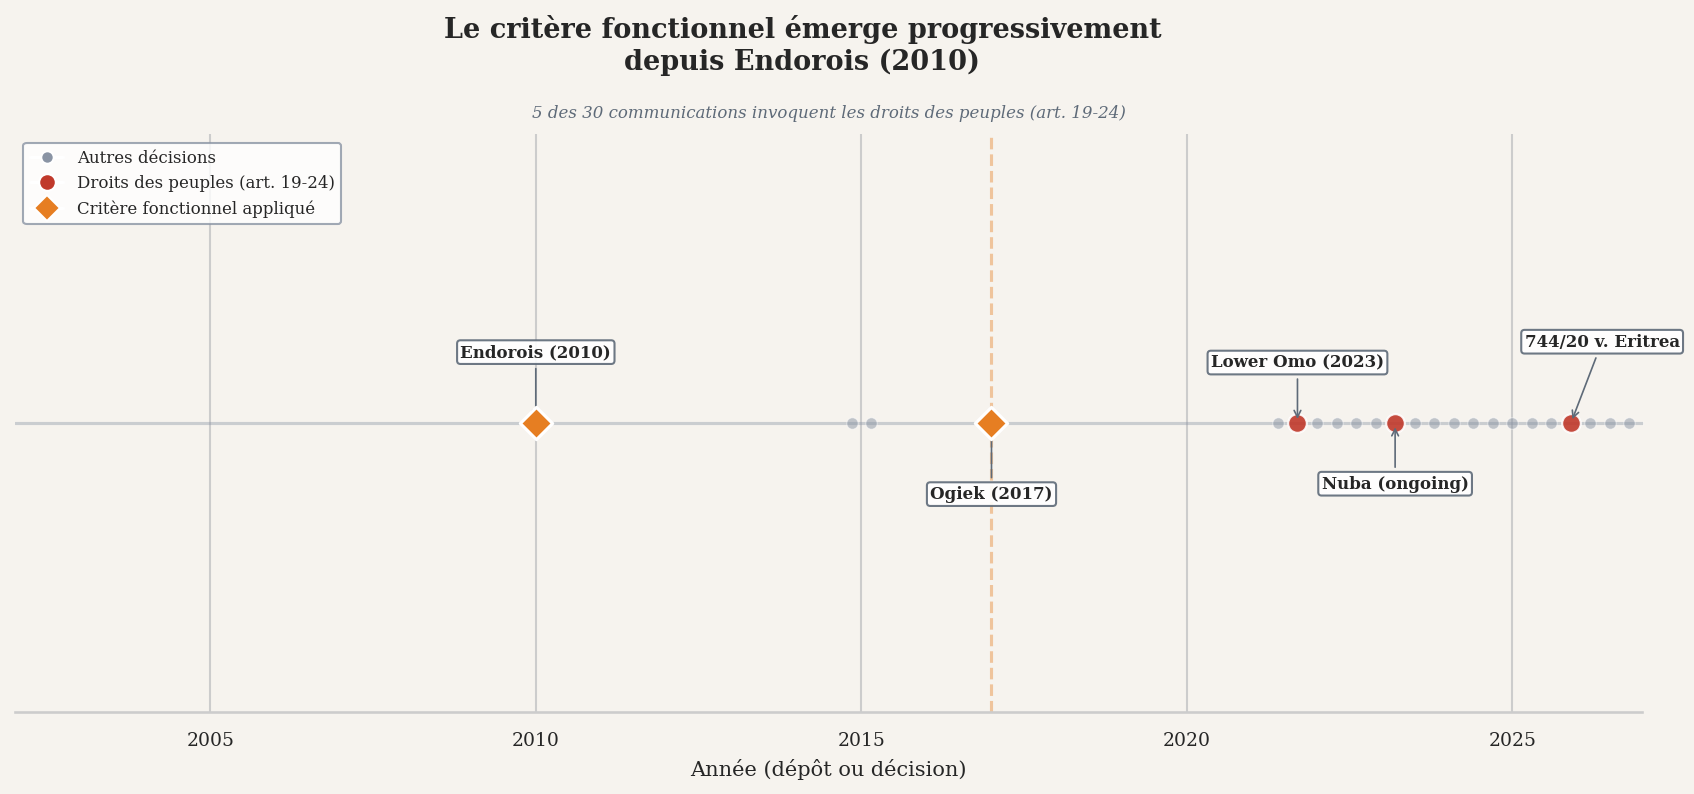

Saved: ch3_case_law_timeline (fr + en)


In [3]:
# ── Data computation (outside lang loop) ──
valid = df.dropna(subset=['year']).copy()
valid = valid.sort_values('year')

others = valid[~valid['has_peoples']]
peoples = valid[valid['has_peoples'] & ~valid['has_functional_criterion']]
func_cases = valid[valid['has_functional_criterion']]

# Handle same-year collisions: offset dots by ±0.3
year_counts = {}
valid['x_pos'] = 0.0
for idx, row in valid.iterrows():
    yr = row['year']
    year_counts.setdefault(yr, [])
    year_counts[yr].append(idx)

for yr, idxs in year_counts.items():
    n = len(idxs)
    if n == 1:
        valid.loc[idxs[0], 'x_pos'] = yr
    else:
        offsets = np.linspace(-0.3 * (n - 1) / 2, 0.3 * (n - 1) / 2, n)
        for i, idx in enumerate(idxs):
            valid.loc[idx, 'x_pos'] = yr + offsets[i]

# Peoples' rights case labels (alternating above/below)
peoples_annotations = {
    '276/03': 'Endorois (2010)',
    '006/2012': 'Ogiek (2017)',
    '419/12': 'Lower Omo (2023)',
    '402/11': 'Nuba (ongoing)',
    '744/20': '744/20 v. Eritrea',
}

# Manual y-offsets for right-side labels to avoid overlap
# Positive = above line, negative = below line
annotation_offsets = {
    '276/03': 30,
    '006/2012': -30,
    '419/12': 25,
    '402/11': -25,
    '744/20': 35,
}

# ── Plot in both languages ──
for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(14, 5))

    # Horizontal timeline line
    ax.axhline(y=0.5, color=C_DIM, linewidth=1.5, alpha=0.4, zorder=1)

    # Other decisions (small dots on the line)
    ax.scatter(valid.loc[others.index, 'x_pos'], [0.5] * len(others),
               s=30, c=C_DIM, alpha=0.5, zorder=2, edgecolors='white', linewidths=0.5)

    # Peoples' rights cases (medium dots on the line)
    ax.scatter(valid.loc[peoples.index, 'x_pos'], [0.5] * len(peoples),
               s=80, c=C_PEOPLES, alpha=0.9, zorder=3, edgecolors='white', linewidths=1)

    # Functional criterion cases (large diamonds on the line)
    ax.scatter(valid.loc[func_cases.index, 'x_pos'], [0.5] * len(func_cases),
               s=120, c=C_FUNC, marker='D', zorder=4, edgecolors='white', linewidths=1.5)

    # Annotate peoples' rights cases with manual offsets
    peoples_all = valid[valid['has_peoples']].sort_values('x_pos')
    for i, (idx, row) in enumerate(peoples_all.iterrows()):
        cn = row['case_number']
        if cn not in peoples_annotations:
            continue
        label = peoples_annotations[cn]
        y_offset = annotation_offsets.get(cn, 25 if i % 2 == 0 else -25)
        x_offset = 15 if cn == '744/20' else 0
        above = y_offset > 0
        va = 'bottom' if above else 'top'
        ax.annotate(label,
                    xy=(valid.loc[idx, 'x_pos'], 0.5),
                    xytext=(x_offset, y_offset), textcoords='offset points',
                    fontsize=8, fontweight='bold', ha='center', va=va,
                    arrowprops=dict(arrowstyle='->', color=C_MUTED, lw=0.8),
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=C_MUTED, alpha=0.9))

    # Ogiek vertical dashed line
    ax.axvline(x=2017, color=C_FUNC, linestyle='--', alpha=0.4, zorder=1)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=C_DIM, markersize=6,
               label=t('legend_other_decisions', lang)),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=C_PEOPLES, markersize=8,
               label=t('legend_peoples_rights', lang)),
        Line2D([0], [0], marker='D', color='w', markerfacecolor=C_FUNC, markersize=9,
               label=t('legend_functional', lang)),
    ]
    ax.legend(handles=legend_elements, loc='upper left', frameon=True, facecolor='white', edgecolor=C_DIM, fontsize=8)

    ax.set_xlabel(t('timeline_xlabel', lang), fontsize=10)
    fig.suptitle(t('timeline_title', lang), fontsize=13, fontweight='bold', fontfamily='serif', y=1.04)
    ax.set_title(t('timeline_subtitle', lang), fontsize=8, color=C_MUTED, style='italic', pad=8)
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.set_ylim(0, 1)
    ax.set_xlim(2002, 2027)

    save_fig(fig, 'ch3_case_law_timeline', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print('Saved: ch3_case_law_timeline (fr + en)')

## 3. Ch.3 — Article Invocation Frequency (Figure 2)

Which articles of the African Charter are most frequently invoked? Peoples' rights articles (19-24) are highlighted.

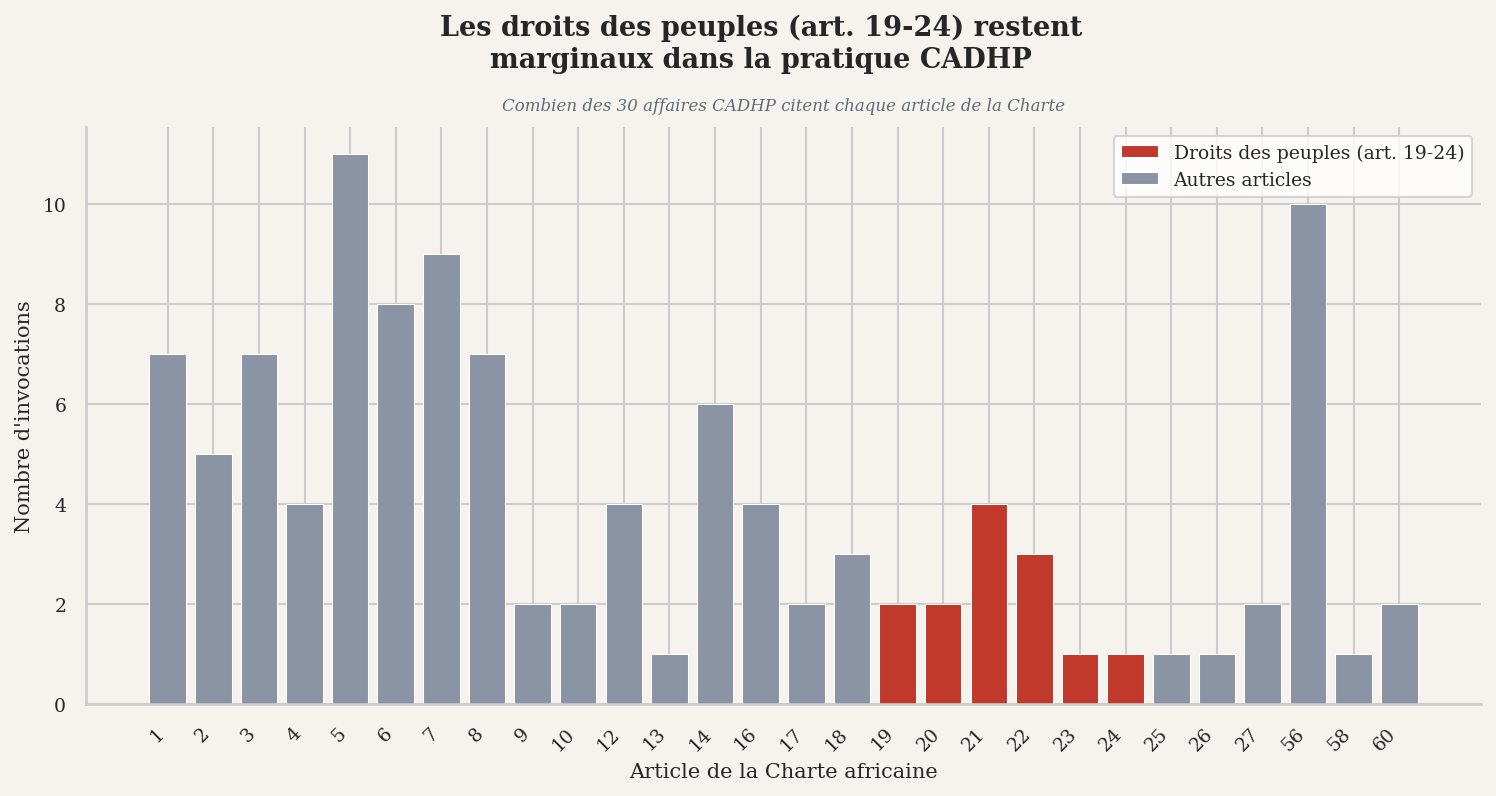

Saved: ch3_article_frequency (fr + en)


In [4]:
# ── Data computation (outside lang loop) ──
art_counter = Counter()
for arts in df['all_articles']:
    for a in arts:
        try:
            art_counter[int(a)] += 1
        except ValueError:
            pass

articles = sorted(art_counter.keys())
counts = [art_counter[a] for a in articles]
peoples_arts = {19, 20, 21, 22, 23, 24}
colors = [C_PEOPLES if a in peoples_arts else C_DIM for a in articles]

# ── Plot in both languages ──
for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar([str(a) for a in articles], counts, color=colors, edgecolor='white', linewidth=0.5)

    legend_elements = [
        mpatches.Patch(facecolor=C_PEOPLES, label=t('legend_peoples_rights', lang)),
        mpatches.Patch(facecolor=C_DIM, label=t('legend_other_articles', lang)),
    ]
    ax.legend(handles=legend_elements, loc='upper right', frameon=True, facecolor='white', fontsize=9)

    ax.set_xlabel(t('article_freq_xlabel', lang), fontsize=10)
    ax.set_ylabel(t('article_freq_ylabel', lang), fontsize=10)
    fig.suptitle(t('article_freq_title', lang), fontsize=13, fontweight='bold', fontfamily='serif', y=1.03)
    ax.set_title(t('article_freq_subtitle', lang), fontsize=8, color=C_MUTED, style='italic', pad=8)
    plt.xticks(rotation=45, ha='right')

    save_fig(fig, 'ch3_article_frequency', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print('Saved: ch3_article_frequency (fr + en)')

## 4. Ch.3 — Functional Criterion Emergence (Figure 3)

Timeline focused on the 5 cases that invoke peoples' rights. Shows the progressive construction of the sub-state peoples category through key legal formulations.

> **Thesis argument (Ch.3):** The ACHPR *constructed* the functional criterion progressively — from Endorois (2010, first explicit recognition of indigenous peoples' rights) through Ogiek (2017, African Court confirmation) to Lower Omo (2023, extended application) and Nuba (ongoing, non-indigenous peoples). The criterion shifted from *who groups are* to *what protections their situation requires*.

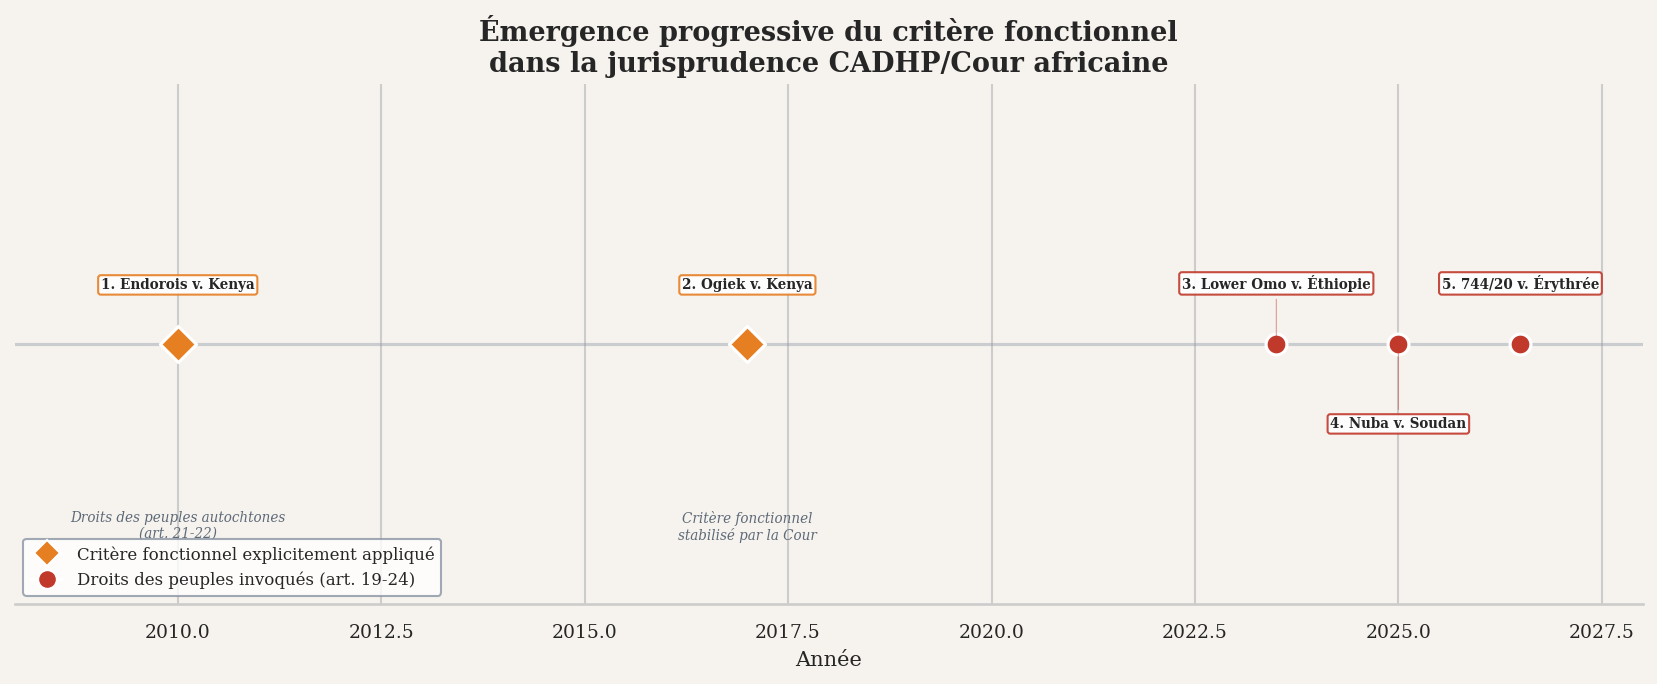

Saved: ch3_functional_criterion_emergence (fr + en)


In [5]:
# ── Bilingual formulations for key cases (short, max 2 lines) ──
formulations = {
    '276/03': {
        'fr': 'Droits des peuples autochtones\n(art. 21-22)',
        'en': 'Indigenous peoples\' rights\n(art. 21-22)',
    },
    '006/2012': {
        'fr': 'Critère fonctionnel\nstabilisé par la Cour',
        'en': 'Functional criterion\nstabilized by Court',
    },
    '419/12': {
        'fr': "Autodétermination +\nressources (art. 20-24)",
        'en': 'Self-determination +\nresources (art. 20-24)',
    },
    '402/11': {
        'fr': "Droits collectifs sans\nqualification « autochtone »",
        'en': "Collective rights without\n'indigenous' qualification",
    },
    '744/20': {
        'fr': "Égalité des peuples\n(art. 19)",
        'en': "Equality of peoples\n(art. 19)",
    },
}

# Focus on peoples' rights cases
key_cases = [
    {
        'name': 'Endorois v. Kenya',
        'case_number': '276/03',
        'year': 2010,
        'functional': True,
    },
    {
        'name': 'Ogiek v. Kenya',
        'case_number': '006/2012',
        'year': 2017,
        'functional': True,
    },
    {
        'name': {'fr': 'Lower Omo v. Éthiopie', 'en': 'Lower Omo v. Ethiopia'},
        'case_number': '419/12',
        'year': 2025,
        'functional': False,
    },
    {
        'name': {'fr': 'Nuba v. Soudan', 'en': 'Nuba v. Sudan'},
        'case_number': '402/11',
        'year': 2025,
        'functional': False,
    },
    {
        'name': {'fr': '744/20 v. Érythrée', 'en': '744/20 v. Eritrea'},
        'case_number': '744/20',
        'year': 2025,
        'functional': False,
    },
]

# X positions: spread cases 3-5 more aggressively
x_positions = [2010, 2017, 2023.5, 2025, 2026.5]
# Y positions for case labels: stagger cases 3-5 vertically
y_label_positions = [0.5, 0.5, 0.7, 0.3, 0.5]

def _case_name(c, lang):
    n = c['name']
    return n[lang] if isinstance(n, dict) else n

# ── Plot in both languages ──
for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(14, 4.5))

    # Horizontal timeline line
    ax.axhline(y=0.5, color=C_DIM, linewidth=1.5, alpha=0.4, zorder=1)

    for i, c in enumerate(key_cases):
        color = C_FUNC if c['functional'] else C_PEOPLES
        marker = 'D' if c['functional'] else 'o'
        size = 150 if c['functional'] else 100
        xp = x_positions[i]
        yp = y_label_positions[i]

        # Dot on the line (always at y=0.5)
        ax.scatter(xp, 0.5, s=size, c=color, marker=marker,
                   zorder=3, edgecolors='white', linewidths=1.5)

        # Case name label — positioned at staggered y for cases 3-5
        name = _case_name(c, lang)
        label_y_offset = 25 if yp >= 0.5 else -35
        label_va = 'bottom' if yp >= 0.5 else 'top'
        ax.annotate(f'{i+1}. {name}',
                    xy=(xp, 0.5), xytext=(0, label_y_offset), textcoords='offset points',
                    fontsize=6.5, fontweight='bold', ha='center', va=label_va,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=color, alpha=0.9),
                    arrowprops=dict(arrowstyle='-', color=color, lw=0.5, alpha=0.5) if yp != 0.5 else None)

        # Short formulation below the line — only for cases 1-2 where there's space
        if i < 2:
            ax.text(xp, 0.18, formulations[c['case_number']][lang],
                    ha='center', va='top', fontsize=6.5, color=C_MUTED,
                    style='italic', linespacing=1.2)

    legend_elements = [
        Line2D([0], [0], marker='D', color='w', markerfacecolor=C_FUNC, markersize=9,
               label=t('legend_functional_explicit', lang)),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=C_PEOPLES, markersize=9,
               label=t('legend_peoples_invoked', lang)),
    ]
    ax.legend(handles=legend_elements, loc='lower left', frameon=True, facecolor='white',
              edgecolor=C_DIM, fontsize=8)

    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.set_ylim(0, 1)
    ax.set_xlim(2008, 2028)
    ax.set_xlabel(t('functional_emergence_xlabel', lang), fontsize=10)
    ax.set_title(t('functional_emergence_title', lang),
                 fontsize=13, fontweight='bold', fontfamily='serif')

    save_fig(fig, 'ch3_functional_criterion_emergence', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print('Saved: ch3_functional_criterion_emergence (fr + en)')


## 5. Ch.4 S1 — Doctrinal Concept Frequency (Figure 4)

Which doctrinal concepts appear in the case law corpus? The thesis argues that the ACHPR does NOT use the thesis's theoretical vocabulary.

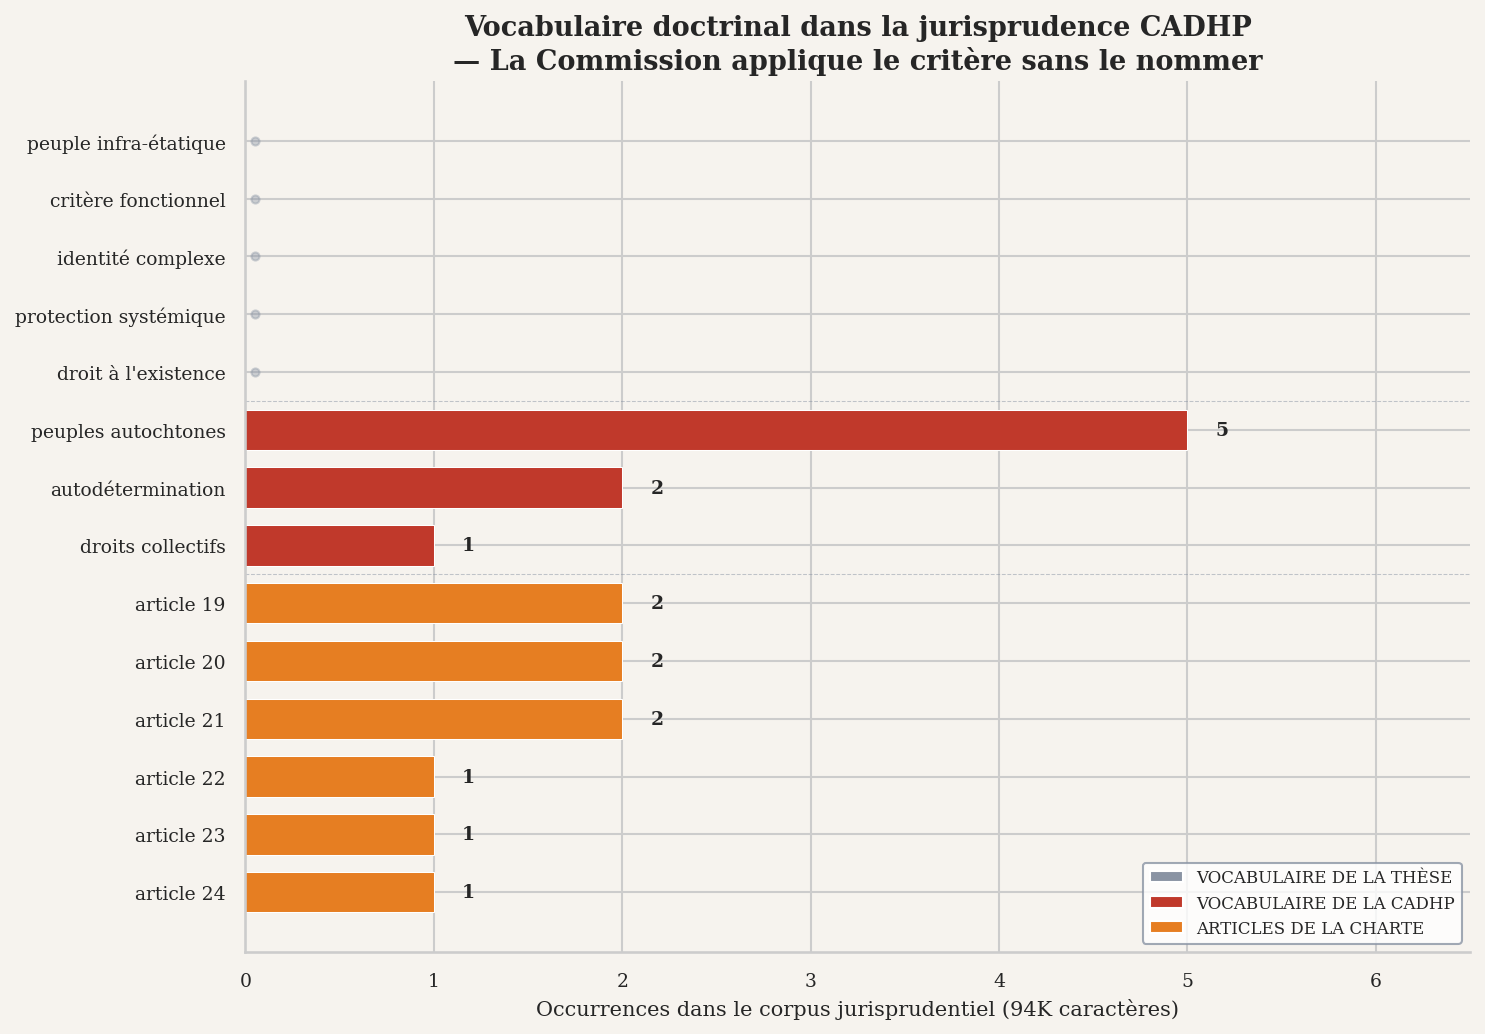

Saved: ch4s1_doctrinal_concepts (fr + en)


In [6]:
# ── Data computation (outside lang loop) ──
concepts = analysis['doctrinal_concepts']

thesis_vocab = ['peuple infra-étatique', 'critère fonctionnel', 'identité complexe',
                'protection systémique', "droit à l'existence"]
charter_articles = ['article 19', 'article 20', 'article 21', 'article 22', 'article 23', 'article 24']
other_concepts = ['peuples autochtones', 'autodétermination', 'droits collectifs']

all_concepts = thesis_vocab + other_concepts + charter_articles
counts_doc = [concepts.get(c, {}).get('count', 0) for c in all_concepts]
colors_bar = ([C_DIM] * len(thesis_vocab) +
              [C_PEOPLES] * len(other_concepts) +
              [C_FUNC] * len(charter_articles))

# ── Plot in both languages ──
for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(10, 7))

    y_pos = range(len(all_concepts))
    bars = ax.barh(y_pos, counts_doc, color=colors_bar, edgecolor='white', linewidth=0.5, height=0.7)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(all_concepts, fontsize=9)
    ax.invert_yaxis()

    for i, (count, concept) in enumerate(zip(counts_doc, all_concepts)):
        if count == 0:
            ax.scatter(0.05, i, marker='o', s=15, color=C_DIM, alpha=0.4, zorder=3)
        else:
            ax.text(count + 0.15, i, str(count), fontsize=9, va='center', fontweight='bold')

    # Horizontal separator lines between groups
    ax.axhline(y=len(thesis_vocab) - 0.5, color=C_DIM, linewidth=0.5, linestyle='--', alpha=0.5)
    ax.axhline(y=len(thesis_vocab) + len(other_concepts) - 0.5, color=C_DIM, linewidth=0.5, linestyle='--', alpha=0.5)

    # Legend explaining the 3 bar color groups (instead of in-plot text labels)
    legend_elements = [
        mpatches.Patch(facecolor=C_DIM, label=t('doctrinal_group_thesis', lang).replace('\n', ' ')),
        mpatches.Patch(facecolor=C_PEOPLES, label=t('doctrinal_group_achpr', lang).replace('\n', ' ')),
        mpatches.Patch(facecolor=C_FUNC, label=t('doctrinal_group_charter', lang).replace('\n', ' ')),
    ]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True, facecolor='white',
              edgecolor=C_DIM, fontsize=8)

    ax.set_xlabel(t('doctrinal_xlabel', lang), fontsize=10)
    ax.set_title(t('doctrinal_title', lang), fontsize=13, fontweight='bold', fontfamily='serif')
    ax.set_xlim(0, max(counts_doc) + 1.5)

    plt.tight_layout()
    save_fig(fig, 'ch4s1_doctrinal_concepts', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print('Saved: ch4s1_doctrinal_concepts (fr + en)')


## 6. Ch.4 S2 — Cross-System Citations (Figure 5)

The ACHPR cites other international systems via articles 60-61 of the Charter. Which systems does it draw from?

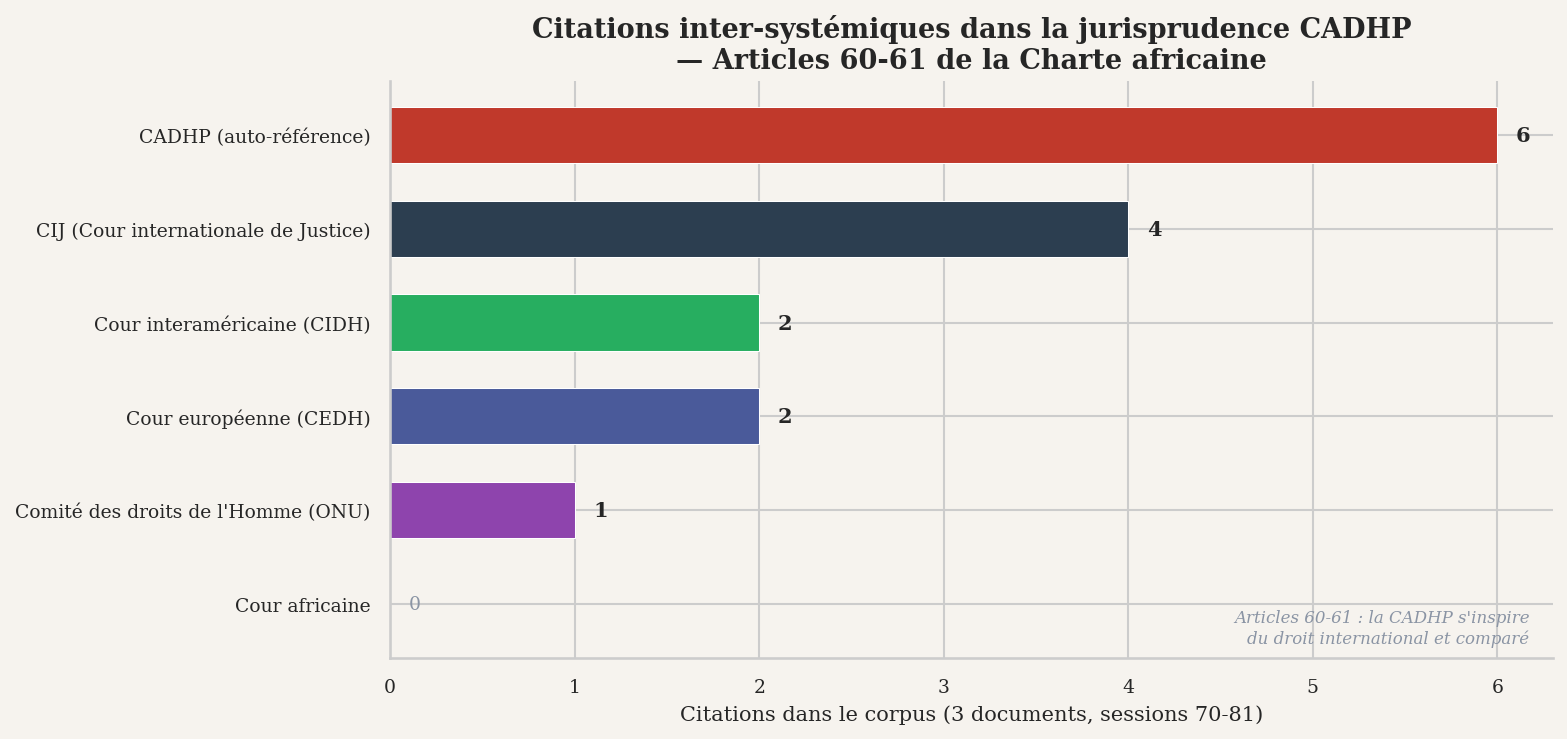

Saved: ch4s2_cross_system_citations (fr + en)


In [7]:
# ── Data computation (outside lang loop) ──
citations = analysis['cross_system_citations']

systems = sorted(citations.keys(), key=lambda s: citations[s]['count'], reverse=True)
counts_cit = [citations[s]['count'] for s in systems]

system_colors = {
    'ACHPR/CADHP': C_PEOPLES,
    'ICJ/CIJ': '#2c3e50',
    'Inter-American (IACHR/CIDH)': '#27ae60',
    'European (ECHR/CEDH)': HC['francophone'],
    'UN HRC': '#8e44ad',
    'African Court': C_FUNC,
}
colors_cit = [system_colors.get(s, C_DIM) for s in systems]

# Map raw system keys to translation keys
_sys_t_key = {
    'ACHPR/CADHP': 'sys_achpr',
    'ICJ/CIJ': 'sys_icj',
    'Inter-American (IACHR/CIDH)': 'sys_iachr',
    'European (ECHR/CEDH)': 'sys_echr',
    'UN HRC': 'sys_unhrc',
    'African Court': 'sys_afcourt',
}

# ── Plot in both languages ──
for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.barh(range(len(systems)), counts_cit, color=colors_cit, edgecolor='white', linewidth=0.5, height=0.6)

    ax.set_yticks(range(len(systems)))
    ax.set_yticklabels([t(_sys_t_key.get(s, s), lang) for s in systems], fontsize=9)
    ax.invert_yaxis()

    for i, count in enumerate(counts_cit):
        if count > 0:
            ax.text(count + 0.1, i, str(count), fontsize=10, va='center', fontweight='bold')
        else:
            ax.text(0.1, i, '0', fontsize=9, va='center', color=C_DIM)

    ax.set_xlabel(t('citations_xlabel', lang), fontsize=10)
    ax.set_title(t('citations_title', lang), fontsize=13, fontweight='bold', fontfamily='serif')

    ax.text(0.98, 0.02, t('citations_note', lang),
            transform=ax.transAxes, fontsize=8, color=C_DIM, style='italic',
            ha='right', va='bottom')

    save_fig(fig, 'ch4s2_cross_system_citations', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print('Saved: ch4s2_cross_system_citations (fr + en)')

## 7. Ch.3/Ch.4 — Landmark Case Citation Network (Figure 6)

Which landmark cases are cited within the corpus? The Nuba case dominates.

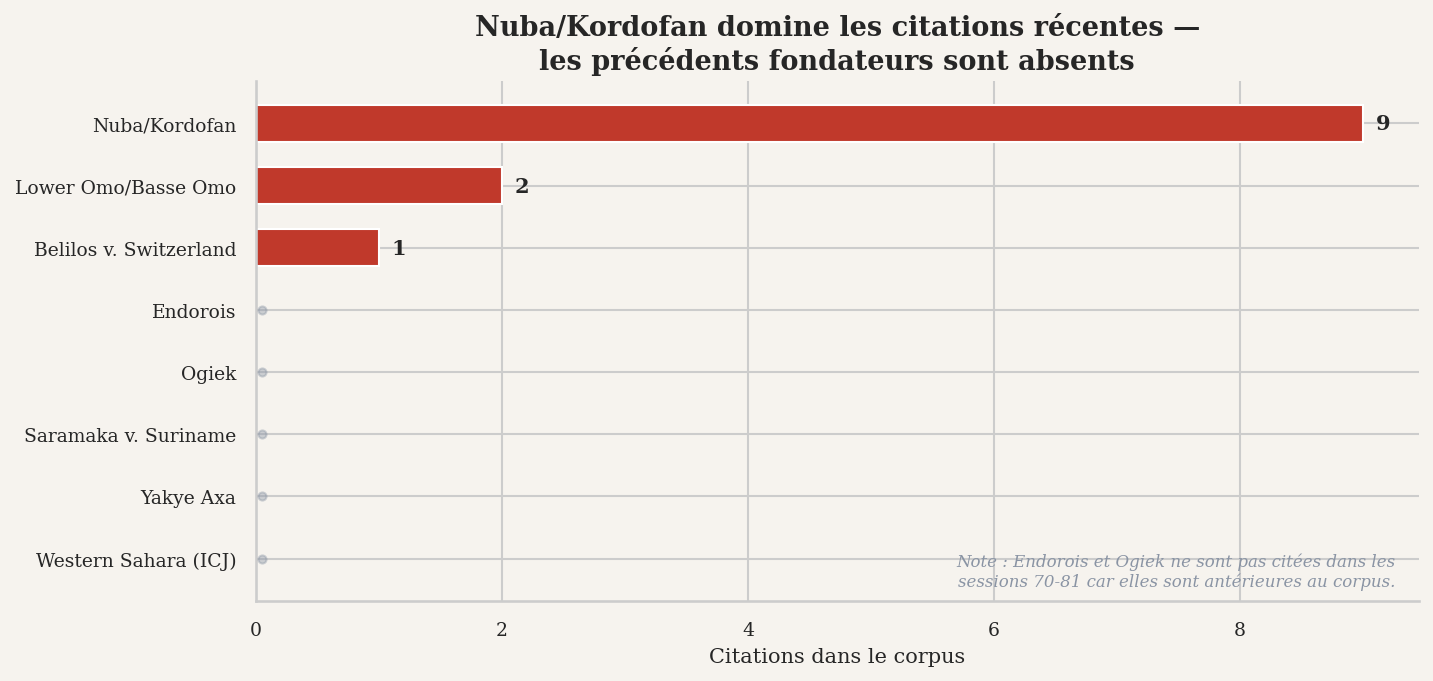

Saved: ch4_landmark_citations (fr + en)


In [8]:
# ── Data computation (outside lang loop) ──
landmarks = analysis['landmark_case_citations']

all_lm = sorted(landmarks.keys(), key=lambda k: landmarks[k], reverse=True)
lm_counts = [landmarks[k] for k in all_lm]
lm_colors = [C_PEOPLES if landmarks[k] > 0 else C_DIM for k in all_lm]

# ── Plot in both languages ──
for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(10, 4.5))

    bars = ax.barh(range(len(all_lm)), lm_counts, color=lm_colors, edgecolor='white', height=0.6)
    ax.set_yticks(range(len(all_lm)))
    ax.set_yticklabels(all_lm, fontsize=9)
    ax.invert_yaxis()

    for i, count in enumerate(lm_counts):
        if count > 0:
            ax.text(count + 0.1, i, str(count), fontsize=10, va='center', fontweight='bold')
        else:
            ax.scatter(0.05, i, marker='o', s=15, color=C_DIM, alpha=0.4, zorder=3)

    ax.set_xlabel(t('landmark_xlabel', lang), fontsize=10)
    ax.set_title(t('landmark_title', lang), fontsize=13, fontweight='bold', fontfamily='serif')

    ax.text(0.98, 0.02, t('landmark_note', lang),
            transform=ax.transAxes, fontsize=8, color=C_DIM, style='italic',
            ha='right', va='bottom')

    save_fig(fig, 'ch4_landmark_citations', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print('Saved: ch4_landmark_citations (fr + en)')

## 8. Ch.5 — Pre/Post-Ogiek Constitutional Evolution

Does the Ogiek decision (2017) correlate with changes in constitutional recognition? We compare constitutions adopted before vs after 2017 across the 10 dimensions.

> **Caveat:** This is a cross-sectional comparison (not causal). Few constitutions were adopted after 2017 in our dataset. The Ogiek effect, if any, would manifest in future constitutional revisions.

In [9]:
features = DATA['features']
feature_labels = DATA['feature_labels']
heritage = DATA['colonial_heritage']
timelines = DATA['country_timelines']

# Score mapping: timeline features are stored as strings (X/P/V)
score_map = {'X': 0, 'P': 1, 'V': 2, 0: 0, 1: 1, 2: 2}

# Get the most recent constitution for each country, split by pre/post 2017
pre_ogiek = []   # constitutions adopted before 2017
post_ogiek = []  # constitutions adopted 2017 or later

for country, entries in timelines.items():
    if country == 'République sahraouie':
        continue
    # Get the most recent entry with feature data
    coded = [e for e in entries if e.get('has_feature_data')]
    if not coded:
        continue
    latest = max(coded, key=lambda e: e['year'])
    record = {f: score_map.get(latest['features'].get(f, 'X'), 0) for f in features}
    record['country'] = country
    record['year'] = latest['year']
    record['heritage'] = heritage.get(country, 'unknown')
    record['total'] = sum(record[f] for f in features)

    if latest['year'] < 2017:
        pre_ogiek.append(record)
    else:
        post_ogiek.append(record)

print(f'Constitutions pre-Ogiek (before 2017): {len(pre_ogiek)}')
print(f'Constitutions post-Ogiek (2017+): {len(post_ogiek)}')

if post_ogiek:
    print(f'\nPost-Ogiek countries:')
    for r in sorted(post_ogiek, key=lambda x: x['year']):
        print(f'  {r["country"]} ({r["year"]}, {r["heritage"]}): total={r["total"]}')

# Compute mean scores per dimension
pre_means = {f: np.mean([r[f] for r in pre_ogiek]) for f in features}
post_means = {f: np.mean([r[f] for r in post_ogiek]) for f in features} if post_ogiek else {}

print(f'\nPre-Ogiek mean total: {np.mean([r["total"] for r in pre_ogiek]):.1f}')
if post_ogiek:
    print(f'Post-Ogiek mean total: {np.mean([r["total"] for r in post_ogiek]):.1f}')


Constitutions pre-Ogiek (before 2017): 40
Constitutions post-Ogiek (2017+): 14

Post-Ogiek countries:
  Mauritanie (2017, francophone): total=6
  Burundi (2018, francophone): total=11
  Comores (2018, francophone): total=10
  Mozambique (2018, lusophone): total=9
  Soudan (2019, anglophone): total=11
  Algérie (2020, francophone): total=8
  Guinée (2021, francophone): total=3
  Tunisie (2022, francophone): total=3
  Mali (2023, francophone): total=10
  République centrafricaine (2023, francophone): total=8
  Tchad (2023, francophone): total=10
  Burkina Faso (2024, francophone): total=9
  Gabon (2024, francophone): total=5
  Togo (2024, francophone): total=6

Pre-Ogiek mean total: 9.2
Post-Ogiek mean total: 7.8


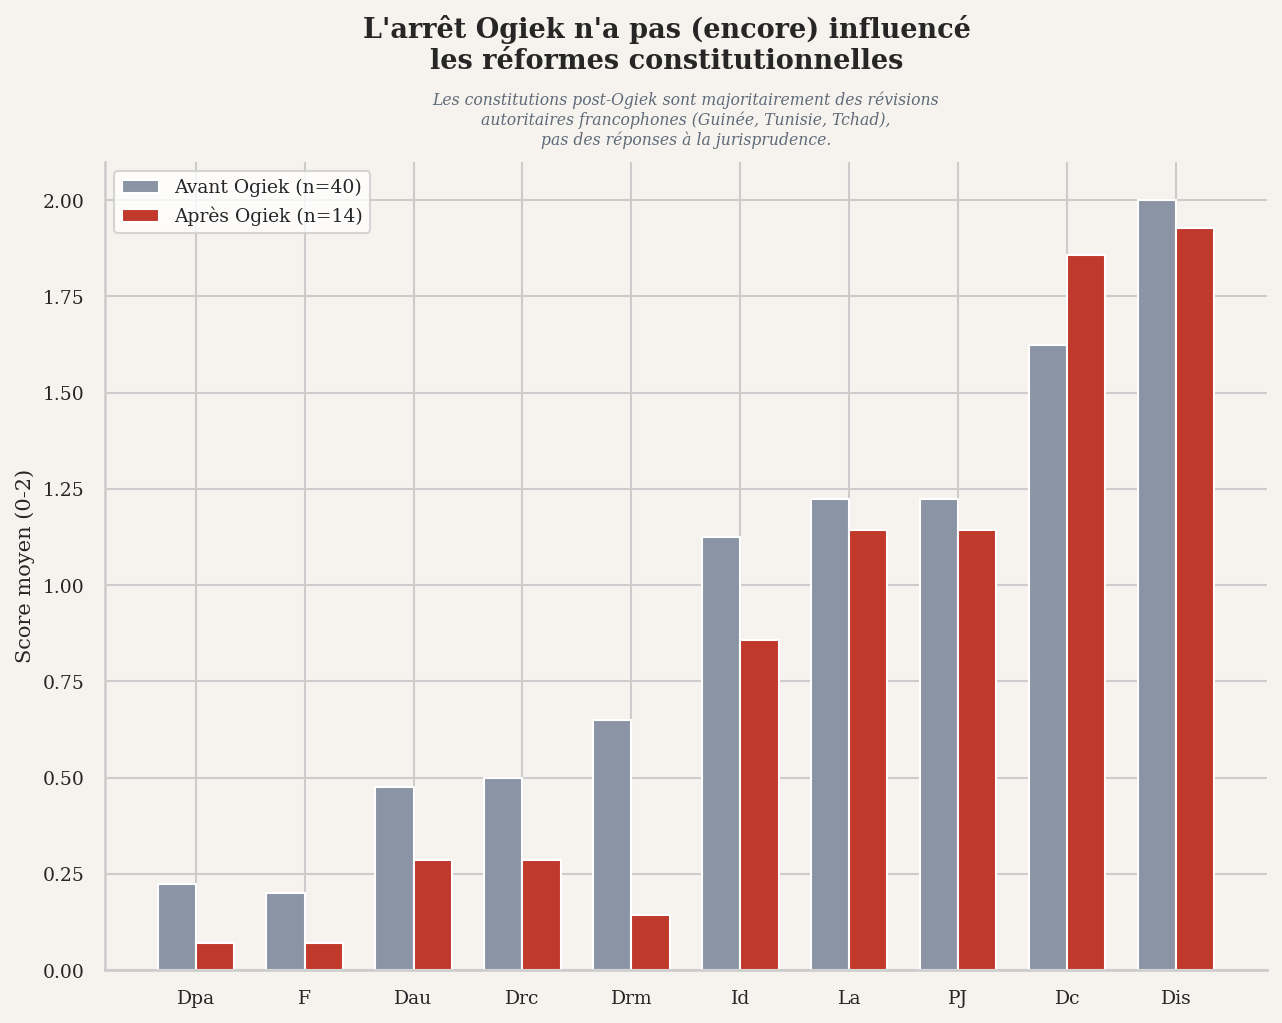

Saved: ch5_pre_post_ogiek (fr + en)


In [10]:
# Figure 7: Pre vs Post-Ogiek comparison
if post_ogiek and len(post_ogiek) >= 3:
    # ── Data computation (outside lang loop) ──
    x = np.arange(len(features))
    width = 0.35
    pre_vals = [pre_means[f] for f in features]
    post_vals = [post_means[f] for f in features]

    # ── Plot in both languages ──
    for lang in ('fr', 'en'):
        fig, ax = plt.subplots(figsize=(10, 7))

        bars1 = ax.bar(x - width/2, pre_vals, width,
                       label=t('pre_ogiek_label', lang).format(len(pre_ogiek)),
                       color=C_DIM, edgecolor='white')
        bars2 = ax.bar(x + width/2, post_vals, width,
                       label=t('post_ogiek_label', lang).format(len(post_ogiek)),
                       color=C_PEOPLES, edgecolor='white')

        ax.set_xticks(x)
        ax.set_xticklabels(features, fontsize=9)
        ax.set_ylabel(t('pre_post_ogiek_ylabel', lang), fontsize=10)
        ax.legend(frameon=True, facecolor='white', fontsize=9)
        fig.suptitle(t('pre_post_ogiek_title', lang),
                     fontsize=13, fontweight='bold', fontfamily='serif', y=1.02)
        ax.set_title(t('pre_post_ogiek_subtitle', lang),
                     fontsize=7.5, color=C_MUTED, style='italic', pad=8)

        save_fig(fig, 'ch5_pre_post_ogiek', lang)
        if lang == 'fr':
            plt.show()
        else:
            plt.close(fig)

    print('Saved: ch5_pre_post_ogiek (fr + en)')
else:
    n_post = len(post_ogiek) if post_ogiek else 0
    print(f'Only {n_post} constitutions adopted after Ogiek (2017).')
    print('Too few for a meaningful comparison figure.')
    print('This is itself a finding: the Ogiek effect, if any, has not yet materialized')
    print('in constitutional revisions — consistent with the thesis argument that')
    print('ACHPR case law constructs the category but constitutional recognition')
    print('depends on domestic political moments (post-conflict).')

## 9. Summary

Key findings from the case law analysis.

In [11]:
print('=' * 60)
print('M3/M5 CASE LAW ANALYSIS — SUMMARY')
print('=' * 60)

print(f'\n--- Dataset ---')
print(f'Total cases analyzed: {len(df)}')
print(f'Cases invoking peoples\' rights (art. 19-24): {df["has_peoples"].sum()}/30')
print(f'Cases with functional criterion: {df["has_functional_criterion"].sum()}/30')
print(f'Cases referencing "autochtone": {df["has_autochtone"].sum()}/30')
print(f'Cases mentioning self-determination: {df["has_self_determination"].sum()}/30')

print(f'\n--- Ch.3: Functional Criterion Emergence ---')
print(f'Endorois (2010): first ACHPR recognition of indigenous peoples\' rights')
print(f'Ogiek (2017): African Court confirmation — criterion stabilized')
print(f'Lower Omo (2025): extension to Omo Valley peoples + self-determination')
print(f'Nuba (2025): applied to non-indigenous peoples (no "autochtone" label)')
print(f'→ Progressive shift from WHO groups are to WHAT protections they need')

print(f'\n--- Ch.4 S1: Doctrinal Concepts ---')
print(f'Thesis vocabulary ABSENT: peuple infra-étatique, critère fonctionnel,')
print(f'  identité complexe, protection systémique, droit à l\'existence')
print(f'ACHPR vocabulary PRESENT: peuples autochtones (5), autodétermination (2),')
print(f'  droits collectifs (1)')
print(f'→ The thesis CONSTRUCTS the category; the Commission APPLIES it without naming it')

print(f'\n--- Ch.4 S2: Cross-System Citations ---')
for s in sorted(citations.keys(), key=lambda k: citations[k]['count'], reverse=True):
    print(f'  {s}: {citations[s]["count"]} citations')
print(f'→ CIJ dominates (4), followed by CADHP auto-reference (6 incl. own jurisprudence)')
print(f'→ Inter-American and European cited (2 each) — articles 60-61 in action')
print(f'→ African Court: 0 citations (corpus covers ACHPR only, not Court decisions)')

print(f'\n--- Ch.5: Pre/Post-Ogiek ---')
n_post = len(post_ogiek) if post_ogiek else 0
print(f'Constitutions adopted after Ogiek (2017): {n_post}')
if n_post < 5:
    print(f'→ Too few for statistical comparison. The Ogiek effect has not yet')
    print(f'  materialized in constitutional text. This supports the thesis:')
    print(f'  case law constructs the category, but constitutional recognition')
    print(f'  depends on domestic political moments (post-conflict).')

print(f'\n--- Figures Generated ---')
import glob
figs = sorted(glob.glob(str(FIG_DIR / 'ch3_*'))) + sorted(glob.glob(str(FIG_DIR / 'ch4*')))
for f in figs:
    print(f'  {Path(f).name}')
if n_post >= 3:
    print(f'  ch5_pre_post_ogiek.pdf/png')

print(f'\n--- Caveats ---')
print(f'1. Dataset is NOT exhaustive (30/~200+ ACHPR decisions)')
print(f'2. Functional criterion coding is preliminary (requires Alex\'s validation)')
print(f'3. Dates are mixed (filing year vs decision date vs session date)')
print(f'4. Cross-system citations only from 3 docx files (sessions 70-81)')

M3/M5 CASE LAW ANALYSIS — SUMMARY

--- Dataset ---
Total cases analyzed: 30
Cases invoking peoples' rights (art. 19-24): 5/30
Cases with functional criterion: 2/30
Cases referencing "autochtone": 3/30
Cases mentioning self-determination: 1/30

--- Ch.3: Functional Criterion Emergence ---
Endorois (2010): first ACHPR recognition of indigenous peoples' rights
Ogiek (2017): African Court confirmation — criterion stabilized
Lower Omo (2025): extension to Omo Valley peoples + self-determination
Nuba (2025): applied to non-indigenous peoples (no "autochtone" label)
→ Progressive shift from WHO groups are to WHAT protections they need

--- Ch.4 S1: Doctrinal Concepts ---
Thesis vocabulary ABSENT: peuple infra-étatique, critère fonctionnel,
  identité complexe, protection systémique, droit à l'existence
ACHPR vocabulary PRESENT: peuples autochtones (5), autodétermination (2),
  droits collectifs (1)
→ The thesis CONSTRUCTS the category; the Commission APPLIES it without naming it

--- Ch.4 S2: